Monte carlo simulatie voor de depressiegraaf

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit
import os


In [2]:
#initializing the graph, hard coded from the board
#we use the connection matrix defined during the yap session
"""
1: Concentratie
2: Traag/Zenuwachtig
3: Suicidaal
4: Laag zelfbeeld
5: Weinig interesse
6: Neerslachtig
7: Slechte slaap
8: Moe
9: Eetstoornis

We doen verbindings_matrix[i,j] is van i naar j
"""
verbindings_matrix = [[0,6,0,0,0,0,0,0,0], 
                      [6,0,0,1,0,0,4,0,0], 
                      [0,0,0,8,3,0,9,0,0], 
                      [0,0,3,7,5,2,1,0,2], 
                      [0,2,1,0,3,0,0,0,1], 
                      [0,2,1,2,7,3,0,0,2], 
                      [0,0,0,1,0,0,1,10,0], 
                      [7,2,0,3,4,4,-3,0,0], 
                      [1,4,0,4,0,0,2,2,1]]
verbindings_matrix = np.array(verbindings_matrix)

extern_veld = [0,0,0,0,0,0,0,0,0] #naar wens aan te passen, kan normaal ook over gesweept worden
extern_veld = np.array(extern_veld)
model_params = [verbindings_matrix, extern_veld]

In [3]:
# Monte carlo simulatie met credits naar prof. Enrico Carlon, aangepast om op de depressiegraaf te runnen

#TODO: @njit weer fixen zodat de code niet meer insane traag is
def initialize_lattice(L):
    """Initialize an LxL lattice with random spins (+1 or -1)."""
    return np.random.choice([-1, 1], size=(L))
@njit
def compute_energy(lattice, intern, extern):
    """Compute the total energy of the lattice."""
    energy = 0
    L = np.size(lattice)
    diag_counter = np.ones(L) #to prevent double counting the diagonal
    for i in range(L):
        external = lattice[i]*extern[i]
        internal = 0
        for j in range(L):
            if i != j:
                internal += lattice[i]*lattice[j]*intern[i][j]
            elif diag_counter[i] == 1:
                internal += lattice[i]*lattice[j]*intern[i][j]
                diag_counter[i] += 1
        energy += external + internal        
    return energy
@njit
def metropolis_step(lattice, beta, intern, extern):
    """Perform one Metropolis update step."""
    L = len(lattice)
    dE = 0
    new_latice = lattice.copy()
    initial_energy = compute_energy(lattice, intern, extern)
    for _ in range(L):
        i = np.random.randint(0, L)
        S = new_latice[i]
        new_latice[i] = -S
        new_E = compute_energy(new_latice, intern, extern)
        delta_E = new_E - initial_energy
        prob = np.exp(beta*delta_E)
        if delta_E < 0 or np.random.rand() < prob:
            lattice[i] *= -1
            dE += delta_E
    return dE
def simulate_ising(L, T, sweeps, equilib_sweeps, parameters):
    intern = parameters[0]
    extern = parameters[1]
    """Simulate the Ising model and compute average energy & energy squared"""
    beta = 1.0 / T
    lattice = initialize_lattice(L)
    #lattices = []
### Precompute an array with the possible values of the energy change
### and Metropolis probabilities
    E = compute_energy(lattice, intern, extern)
    for _ in range(equilib_sweeps):
        E += metropolis_step(lattice, beta, intern, extern)
    E_total=E;E2_total=E**2
    for _ in range(sweeps):
        E += metropolis_step(lattice, beta, intern, extern)
        E_total += E
        E2_total += E**2
    E_avg=E_total/sweeps;E2_avg=E2_total/sweeps
    return E_avg, E2_avg, lattice
def compute_model(parameters, L, T_values, sweeps, equilib_sweeps=100, compute_cv = True):
    """Compute specific heat over a range of temperatures."""
    C_V_values = []
    lattices = []
    for T in T_values:
    # print(f"T: {T:.2f}")
        E_avg, E2_avg, latc = simulate_ising(L, T, sweeps, equilib_sweeps, parameters)
        if compute_cv:
            C_V = (E2_avg - E_avg**2) / (T**2 * L**2)
            C_V_values.append(C_V)
        lattices.append(latc)
    if compute_cv:
        return C_V_values, np.array(lattices)
    else:
        return np.array(lattices)
### Simulation Parameters
L = 9 # Lattice size
T_values = [1,2,3,4,5,6,7,8,9,10] # Temperature range
sweeps = 10000 # Number of Monte Carlo sweeps
equilib_sweeps = 100 # Number of equilibration sweeps
# Compute Specific Heat
C_V_values, lattices = compute_model(model_params, L, T_values, sweeps, equilib_sweeps)
# print('C_V_values:', C_V_values)
# Plot the Results
"""
plt.figure(figsize=(8, 5))
plt.plot(T_values, C_V_values, 'bo-', label='Specific Heat')
plt.xlabel('Temperature (T)')
plt.ylabel('Specific Heat ($C_V$)')
plt.title('Specific Heat vs Temperature in 2D Ising Model')
plt.legend()
plt.grid()
plt.show()
"""

"\nplt.figure(figsize=(8, 5))\nplt.plot(T_values, C_V_values, 'bo-', label='Specific Heat')\nplt.xlabel('Temperature (T)')\nplt.ylabel('Specific Heat ($C_V$)')\nplt.title('Specific Heat vs Temperature in 2D Ising Model')\nplt.legend()\nplt.grid()\nplt.show()\n"

In [4]:
def data_extracter(map_path, generic_filename, all_data = True):
    # Neemt de path van de map die je wilt inlezen en een generic filenaam. Itereert over alle files in de map en zal dan de data teruggeven
    # Als all_data = True krijg je een 3d array met alle lattices, als all_data = False krijg je enkel gemiddeldes van de lattice waardes 
    # over de verschillende runs heen
    # Informatie over de temperaturen worden niet meteen gegeven, die moet je terugzoeken in de Info file.
    dir_path = map_path
    aant_files = len([entry for entry in os.listdir(dir_path) if os.path.isfile(os.path.join(dir_path, entry))])
    big_data = []
    for i in range(aant_files):
        filenaam = dir_path + "\\" + generic_filename + str(i+1)
        file_data = np.loadtxt(filenaam, ndmin=2)
        file_data = np.array(file_data)
        big_data.append(file_data)
    big_data = np.array(big_data)
    averaged_data = np.mean(big_data, axis=0)
    if all_data:
        return averaged_data, big_data
    else:
        return averaged_data

#Disclaimer (danku mr. Duwel), map_path moet gewoon de naam zijn van de map, als je een backslash toevoegt wordt het een globaal pad en ben je cooked
# "h=0_sweeps" is dus correct,
# "\h=0_sweeps" niet

In [5]:
#Voorbeeld van de werking van data_extracter
small, big = data_extracter("h=0_sweeps", "Data_sweeps_run_", True)
small

array([[ 0.08181818, -0.07272727, -0.05454545, ..., -0.02727273,
         0.        , -0.04545455],
       [ 0.05454545, -0.09090909,  0.07272727, ...,  0.05454545,
         0.07272727, -0.10909091],
       [ 0.05454545,  0.16363636,  0.01818182, ...,  0.00909091,
        -0.02727273,  0.16363636],
       ...,
       [ 0.03636364,  0.05454545, -0.00909091, ...,  0.        ,
         0.01818182,  0.04545455],
       [ 0.08181818,  0.07272727,  0.03636364, ...,  0.05454545,
         0.07272727, -0.09090909],
       [ 0.09090909,  0.02727273, -0.06363636, ..., -0.00909091,
         0.        ,  0.08181818]], shape=(200, 9))

In [10]:
def gather_data(externe_invloed, numruns, temperaturen, save_data = None, give_big_data = False, report_runs = None, L = 9, verbindings_matrix = verbindings_matrix, cv = False):
    # externe_invloed, numruns en temperaturen zou je zelf moeten kunnen interpreteren
    # Als save_data = None slagen we de data niet op, als je iets meegeeft zou het van de vorm ["Map naam", "Generic_filename_"] moeten zijn
    # Als report_runs niet None is zou het een int moeten zijn en geeft het weer hoe vaak je geupdate wilt worden over het aantal vervolledigde runs
    # cv geeft de optie om ook warmtecapaciteit te bepalen
    big_data = np.empty((len(temperaturen), L, numruns))
    model_parameters = [verbindings_matrix, externe_invloed]
    for i in range(numruns):
        if not cv:
            lattices = compute_model(model_parameters, L, temperaturen, sweeps, equilib_sweeps, cv)
        else:
            pass #Nog geen zin om dit te implementeren lol
        big_data[:,:,i] = lattices
        if report_runs is not None:
            if (i+1)%report_runs == 0:
                print("Run " + str(i+1) + " completed")
    big_data = np.array(big_data)
    averages = np.mean(big_data, axis = 2)
    if save_data is not None:
        folder_naam = save_data[0]
        generic = save_data[1]
        path_general = folder_naam + generic
        for i in range(numruns):
            np.savetxt(path_general + str(i+1), big_data[:,:,i])
    if give_big_data:
        return averages, big_data
    else:
        return averages

"""num_runs = 20
T_sweep = np.logspace(-2, 4, 200)
big_matrix = np.empty((len(T_sweep),L,num_runs))
for i in range(num_runs):
    unimportant, lattices = compute_model(model_params, L, T_sweep, sweeps, equilib_sweeps)
    big_matrix[:,:,i] = lattices
    print("Run " + str(i+1) + " completed")

averages = np.mean(big_matrix, axis=2)
averages"""


'num_runs = 20\nT_sweep = np.logspace(-2, 4, 200)\nbig_matrix = np.empty((len(T_sweep),L,num_runs))\nfor i in range(num_runs):\n    unimportant, lattices = compute_model(model_params, L, T_sweep, sweeps, equilib_sweeps)\n    big_matrix[:,:,i] = lattices\n    print("Run " + str(i+1) + " completed")\n\naverages = np.mean(big_matrix, axis=2)\naverages'

[1.00000000e-02 1.07189132e-02 1.14895100e-02 1.23155060e-02
 1.32008840e-02 1.41499130e-02 1.51671689e-02 1.62575567e-02
 1.74263339e-02 1.86791360e-02 2.00220037e-02 2.14614120e-02
 2.30043012e-02 2.46581108e-02 2.64308149e-02 2.83309610e-02
 3.03677112e-02 3.25508860e-02 3.48910121e-02 3.73993730e-02
 4.00880633e-02 4.29700470e-02 4.60592204e-02 4.93704785e-02
 5.29197874e-02 5.67242607e-02 6.08022426e-02 6.51733960e-02
 6.98587975e-02 7.48810386e-02 8.02643352e-02 8.60346442e-02
 9.22197882e-02 9.88495905e-02 1.05956018e-01 1.13573336e-01
 1.21738273e-01 1.30490198e-01 1.39871310e-01 1.49926843e-01
 1.60705282e-01 1.72258597e-01 1.84642494e-01 1.97916687e-01
 2.12145178e-01 2.27396575e-01 2.43744415e-01 2.61267523e-01
 2.80050389e-01 3.00183581e-01 3.21764175e-01 3.44896226e-01
 3.69691271e-01 3.96268864e-01 4.24757155e-01 4.55293507e-01
 4.88025158e-01 5.23109931e-01 5.60716994e-01 6.01027678e-01
 6.44236351e-01 6.90551352e-01 7.40196000e-01 7.93409667e-01
 8.50448934e-01 9.115888

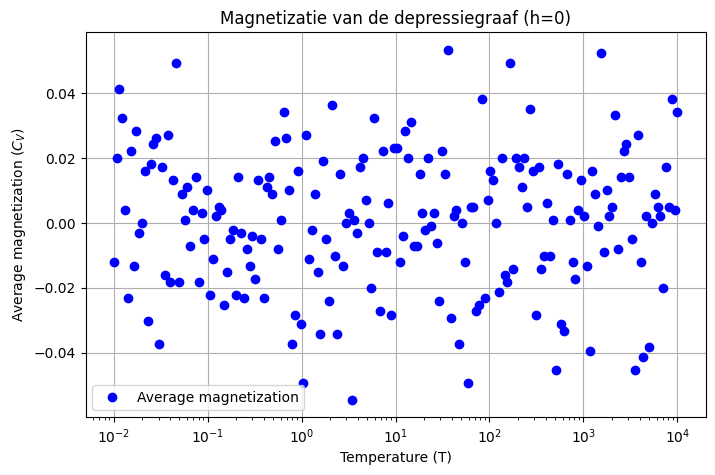

In [7]:
magnetization = np.mean(small, axis=1)
T_sweep = np.logspace(-2,4,200)
print(T_sweep)
plt.figure(figsize=(8, 5))
plt.semilogx(T_sweep, magnetization, 'bo', label='Average magnetization')
plt.xlabel('Temperature (T)')
plt.ylabel('Average magnetization ($C_V$)')
plt.title('Magnetizatie van de depressiegraaf (h=0)')
plt.legend()
plt.grid()
plt.show()

In [11]:
shit_examen_model = [-5,8,0,2,2,0,3,6,0]
ex_temps = np.linspace(5,400,200)

examen_gemiddeldes, examen_big = gather_data(shit_examen_model, 50, ex_temps, "Examen_model\\Examen_run_", True, 5)

Run 5 completed
Run 10 completed
Run 15 completed
Run 20 completed
Run 25 completed
Run 30 completed
Run 35 completed
Run 40 completed
Run 45 completed
Run 50 completed


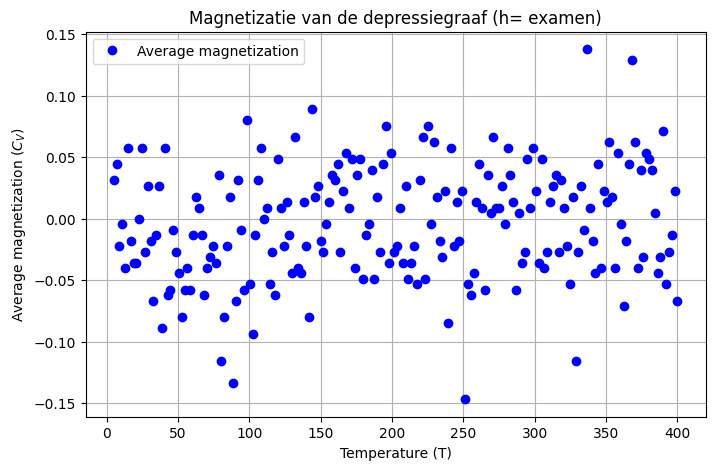

np.float64(-0.0041111111111111105)

In [14]:
ex_magnetization = np.mean(examen_gemiddeldes, axis=1)
plt.figure(figsize=(8, 5))
plt.plot(ex_temps, ex_magnetization, 'bo', label='Average magnetization')
plt.xlabel('Temperature (T)')
plt.ylabel('Average magnetization ($C_V$)')
plt.title('Magnetizatie van de depressiegraaf (h= examen)')
plt.legend()
plt.grid()
plt.show()
np.mean(ex_magnetization)